# Tier 0: learned intraday impulse response vs equal-weight `r_ROD`

A **price-only** prototype for the market-intraday-momentum signal (no alternative data — Tier 0 in `wiki/concepts/MarketIntradayMomentum.md`).

The Baltussen et al. (2020) predictor is `r_ROD` = the **equal-weighted sum** of the day's intraday returns, used to predict the last-half-hour return `r_LH`. System identification (predictive filtering, `wiki/concepts/SysIDReturnPrediction.md`) instead **learns the weights** `g_k` over the intraday lags: `r_LH ≈ Σ_k g_k r_k`. `r_ROD` is the special case `g = const`.

We compare three estimators of that intraday filter:
- **`r_ROD`** — equal weights (1 free coefficient);
- **OLS intraday IR** — least-squares weights (overfits at low SNR);
- **kernel intraday IR** — weights with a smooth prior, marginal-likelihood-tuned (the Tier-0 sysID approach; cf. `kernel_bayesian_id.ipynb`).

> **Synthetic data.** We don't have intraday futures data loaded here, so we simulate a realistic low-SNR, recency-weighted DGP to demonstrate the *methodology* and *when each estimator wins*. Numbers are illustrative, not an empirical result.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.linalg import cho_factor, cho_solve

rng = np.random.default_rng(0)

## Synthetic intraday DGP

`M` intraday return buckets before the last half-hour (bucket 0 = overnight … bucket `M-1` = second-to-last 30 min). The true predictive weights are **recency-weighted** (recent buckets predict `r_LH` more) and smooth — so equal-weight `r_ROD` is *misspecified* but still useful. Population R² is set to a realistic few percent.

M=13 buckets, N=5000 days, population R^2=4%, sigma_eps=9.18


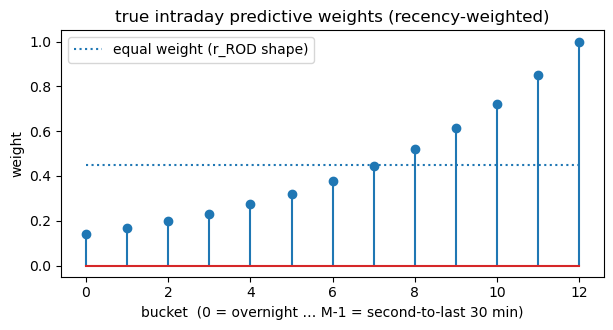

In [2]:
M       = 13       # intraday buckets before the last half-hour (incl. overnight)
N       = 5000     # trading days (synthetic)
R2_POP  = 0.04     # population R^2 of the true model (realistic for this signal)
RHO_TRUE = 0.85    # recency weighting: recent buckets predict r_LH more

lags   = np.arange(M)                     # 0 = oldest (overnight), M-1 = most recent (SLH)
g_true = RHO_TRUE ** (M - 1 - lags)       # smooth decay toward older buckets
X      = rng.standard_normal((N, M))      # intraday half-hour returns (iid, unit scale)
signal = X @ g_true
sigma_eps = np.sqrt(np.var(signal) * (1 - R2_POP) / R2_POP)
y      = signal + sigma_eps * rng.standard_normal(N)    # r_LH

print(f"M={M} buckets, N={N} days, population R^2={R2_POP:.0%}, sigma_eps={sigma_eps:.2f}")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.stem(lags, g_true)
ax.plot(lags, np.full(M, g_true.mean()), "C0:", label="equal weight (r_ROD shape)")
ax.set_title("true intraday predictive weights (recency-weighted)")
ax.set_xlabel("bucket  (0 = overnight … M-1 = second-to-last 30 min)")
ax.set_ylabel("weight"); ax.legend(); plt.show()

## Estimators

All three are fit on demeaned data (the OOS benchmark is the training mean, as in the paper's OOS R²). The kernel IR places a smooth Gaussian prior on the weight vector, `g ~ N(0, λK)` with `K_{ij} = ρ^{|i-j|}`, and tunes `(ρ, λ, σ²)` by **marginal likelihood** — computed in **weight space** (M×M), so it is fast.

In [3]:
def fit_rod(Xtr, ytr):
    xb, yb = Xtr.mean(0), ytr.mean()
    x = (Xtr - xb).sum(1)
    b = (x @ (ytr - yb)) / (x @ x)
    return xb, yb, b

def pred_rod(p, X):
    xb, yb, b = p
    return yb + b * (X - xb).sum(1)

def fit_ols_ir(Xtr, ytr):
    xb, yb = Xtr.mean(0), ytr.mean()
    g, *_ = np.linalg.lstsq(Xtr - xb, ytr - yb, rcond=None)
    return xb, yb, g

def pred_ir(p, X):
    xb, yb, g = p
    return yb + (X - xb) @ g

def smooth_kernel(M, rho):
    idx = np.arange(M)
    return rho ** np.abs(np.subtract.outer(idx, idx))

def fit_kernel_ir(Xtr, ytr):
    xb, yb = Xtr.mean(0), ytr.mean()
    Xc, yc = Xtr - xb, ytr - yb
    G, b, n, m = Xc.T @ Xc, Xc.T @ yc, len(yc), Xtr.shape[1]
    yy = yc @ yc

    def nll(theta):
        rho = 1.0 / (1.0 + np.exp(-theta[0]))      # (0,1)
        lam, s2 = np.exp(theta[1]), np.exp(theta[2])
        K = smooth_kernel(m, rho)
        Lk = np.linalg.cholesky(K)
        logdetK = 2.0 * np.sum(np.log(np.diag(Lk)))
        Kinv = cho_solve((Lk, True), np.eye(m))
        A = Kinv / lam + G / s2                     # posterior precision (M x M)
        La, low = cho_factor(A, lower=True)
        logdetA = 2.0 * np.sum(np.log(np.diag(La)))
        Ainvb = cho_solve((La, low), b)
        quad = yy / s2 - (b @ Ainvb) / s2**2        # y' C^-1 y
        logdetC = n * np.log(s2) + logdetA + m * np.log(lam) + logdetK
        return 0.5 * (n * np.log(2 * np.pi) + logdetC + quad)

    theta0 = np.array([1.0, np.log(np.var(ytr) / m), np.log(np.var(ytr))])
    res = minimize(nll, theta0, method="Nelder-Mead",
                   options=dict(maxiter=3000, xatol=1e-6, fatol=1e-6))
    rho = 1.0 / (1.0 + np.exp(-res.x[0]))
    lam, s2 = np.exp(res.x[1]), np.exp(res.x[2])
    K = smooth_kernel(m, rho)
    A = np.linalg.inv(K) / lam + G / s2
    g = np.linalg.solve(A, b / s2)                  # posterior mean weights
    return (xb, yb, g), (rho, lam, s2)

def oos_r2(y_true, y_pred, y_bench):
    return 1.0 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_bench)**2)

## Single train / test split

In [4]:
ntr = 3500
Xtr, ytr, Xte, yte = X[:ntr], y[:ntr], X[ntr:], y[ntr:]
ybar = ytr.mean()

p_rod = fit_rod(Xtr, ytr)
p_ols = fit_ols_ir(Xtr, ytr)
p_ker, hp = fit_kernel_ir(Xtr, ytr)

preds = {
    "r_ROD (equal weight)": pred_rod(p_rod, Xte),
    "OLS intraday IR":      pred_ir(p_ols, Xte),
    "kernel intraday IR":   pred_ir(p_ker, Xte),
}
print(f"train = {ntr} days, test = {len(yte)} days\n")
print(f"{'method':<24}{'OOS R^2':>10}{'OOS Sharpe':>12}")
print("-" * 46)
for name, pr in preds.items():
    r2 = oos_r2(yte, pr, ybar)
    pnl = np.sign(pr - ybar) * yte
    sharpe = pnl.mean() / pnl.std() * np.sqrt(252)
    print(f"{name:<24}{r2:>10.4f}{sharpe:>12.2f}")
print(f"\nkernel hyperparameters: rho={hp[0]:.3f}, lambda={hp[1]:.3g}, sigma^2={hp[2]:.3g}")
print(f"(population R^2 = {R2_POP:.0%})")

train = 3500 days, test = 1500 days

method                     OOS R^2  OOS Sharpe
----------------------------------------------
r_ROD (equal weight)        0.0366        2.85
OLS intraday IR             0.0467        3.29
kernel intraday IR          0.0492        3.17

kernel hyperparameters: rho=0.973, lambda=0.403, sigma^2=86.5
(population R^2 = 4%)


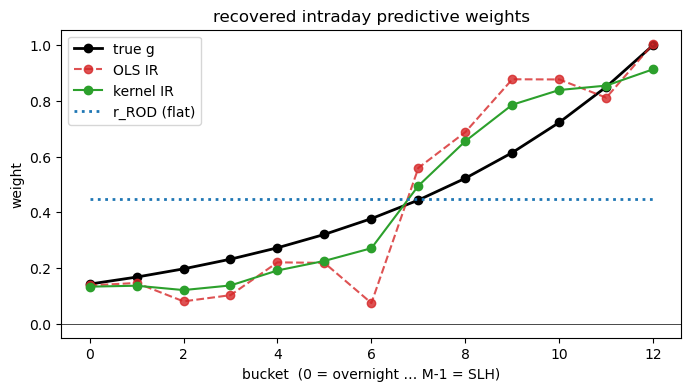

In [5]:
# recovered weights vs the truth
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lags, g_true, "k-o", lw=2, label="true g")
ax.plot(lags, p_ols[2], "C3--o", alpha=0.8, label="OLS IR")
ax.plot(lags, p_ker[2], "C2-o", label="kernel IR")
ax.plot(lags, np.full(M, p_rod[2]), "C0:", lw=2, label="r_ROD (flat)")
ax.set_title("recovered intraday predictive weights")
ax.set_xlabel("bucket  (0 = overnight … M-1 = SLH)"); ax.set_ylabel("weight")
ax.axhline(0, color="k", lw=0.5); ax.legend(); plt.show()

**Reading.** `r_ROD` is forced flat, so it under-weights the recent buckets that matter most → it leaves R² on the table. The OLS IR recovers the right *shape* but is wiggly (variance). The kernel IR recovers a smooth profile close to the truth and gets the highest OOS R² / Sharpe.

## How it depends on sample size

Estimating `M` weights is only worth it with enough data. Below: as training size grows, OLS IR goes from *worse than `r_ROD`* (overfits) to *better* (low bias); the kernel IR is robust throughout; `r_ROD` is stable but biased (capped below the population R²).

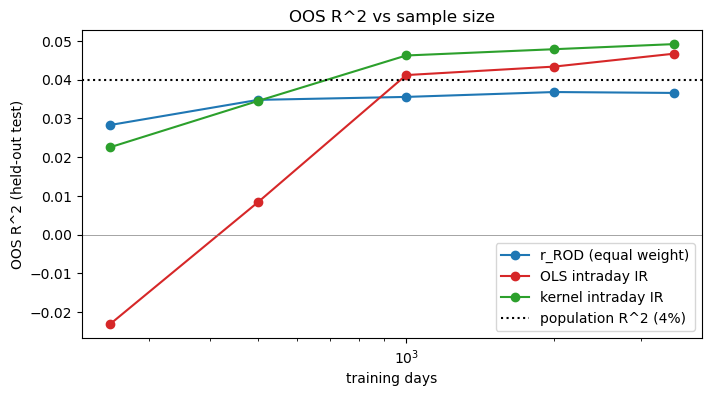

train: [250, 500, 1000, 2000, 3500]
rod  : [np.float64(0.0283), np.float64(0.0348), np.float64(0.0356), np.float64(0.0368), np.float64(0.0366)]
ols  : [np.float64(-0.0231), np.float64(0.0084), np.float64(0.0412), np.float64(0.0434), np.float64(0.0467)]
ker  : [np.float64(0.0226), np.float64(0.0345), np.float64(0.0463), np.float64(0.0479), np.float64(0.0492)]


In [6]:
Xte2, yte2 = X[3500:], y[3500:]
train_sizes = [250, 500, 1000, 2000, 3500]
r2_rod, r2_ols, r2_ker = [], [], []
for ntr in train_sizes:
    Xtr, ytr = X[:ntr], y[:ntr]; yb = ytr.mean()
    r2_rod.append(oos_r2(yte2, pred_rod(fit_rod(Xtr, ytr), Xte2), yb))
    r2_ols.append(oos_r2(yte2, pred_ir(fit_ols_ir(Xtr, ytr), Xte2), yb))
    pk, _ = fit_kernel_ir(Xtr, ytr)
    r2_ker.append(oos_r2(yte2, pred_ir(pk, Xte2), yb))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_sizes, r2_rod, "C0-o", label="r_ROD (equal weight)")
ax.plot(train_sizes, r2_ols, "C3-o", label="OLS intraday IR")
ax.plot(train_sizes, r2_ker, "C2-o", label="kernel intraday IR")
ax.axhline(R2_POP, color="k", ls=":", label=f"population R^2 ({R2_POP:.0%})")
ax.axhline(0, color="grey", lw=0.5)
ax.set_xscale("log"); ax.set_xlabel("training days"); ax.set_ylabel("OOS R^2 (held-out test)")
ax.set_title("OOS R^2 vs sample size"); ax.legend(); plt.show()

print("train:", train_sizes)
print("rod  :", [round(v, 4) for v in r2_rod])
print("ols  :", [round(v, 4) for v in r2_ols])
print("ker  :", [round(v, 4) for v in r2_ker])

## Conclusions

* **Tier 0, price-only:** a learned intraday IR beats equal-weight `r_ROD` **when the true intraday weighting is non-flat** (here, recency-weighted) — `r_ROD` is a robust but *biased* special case.
* **Regularization is the enabler at low SNR:** plain OLS over the lag weights overfits and can be *worse* than `r_ROD` with limited data; the **kernel/Bayesian smooth prior** (marginal-likelihood-tuned) recovers the weight shape and is robust across sample sizes — exactly the [[PyMORDataDrivenID|Bayesian-TIB]] argument applied to the intraday filter.
* **Caveats:** synthetic data — the real test needs intraday futures returns; gains are modest (a few bps of R²), and `r_ROD` remains a strong baseline. If the true weighting were genuinely flat, `r_ROD` would be optimal and the IR would add nothing.
* **Next levers:** Tier 1/2 (LETF rebalancing, MOC imbalance, dealer-gamma/NGE regime-gating) — see `wiki/concepts/MarketIntradayMomentum.md`.